# 0. Run Bash Script
Run `clean-all-data.sh` in a terminal to clean the data and produce the sql files

In [26]:
try:
    %pip install --user "oracledb" --no-warn-script-location
except Exception as e:
    print("Install error")
    raise

import matplotlib.pyplot as plt
import oracledb

Note: you may need to restart the kernel to use updated packages.


In [27]:
import oracledb
import pandas as pd # for parsing data from sql
from scipy.stats import ttest_ind # for graphs

dsn = oracledb.makedsn("127.0.0.1", 1522, service_name="stu")

connection = oracledb.connect(
    user="ora_nmui01",
    password="a98821523",
    dsn=dsn
)

print("Connected to Oracle")

Connected to Oracle


# 1. Run this cell

In [5]:
cur = connection.cursor()
try:
    cur.execute("DROP TABLE countries_relation")
except:
    print("no countries_relation")

try:
    cur.execute("DROP TABLE netflix_prices")
except:
    print("no netflix_prices")

try:
    cur.execute("DROP TABLE netflix_traffic")
except:
    print("no netflix_traffic")

try:
    cur.execute("DROP TABLE worldbank")
except:
    print("no worldbank")

cur.execute("PURGE RECYCLEBIN")

no countries_relation
no netflix_prices
no netflix_traffic
no worldbank


# 2. Before querying
- Copy the .sql files in out to a folder on the cs server
- Connect to oracle db **in that folder**
- Drop everything (optional, but sometimes needed bcs oracle is finicky)
```sql
BEGIN
  FOR t IN (SELECT table_name FROM user_tables) LOOP
    EXECUTE IMMEDIATE 'DROP TABLE ' || t.table_name || ' CASCADE CONSTRAINTS';
  END LOOP;
END;
/

BEGIN
  FOR i IN (SELECT view_name FROM user_views) LOOP
    EXECUTE IMMEDIATE 'DROP VIEW "' || i.view_name || '"';
  END LOOP;
END;
/
```
- Run
```sql
start countries_relation.sql;
start netflix_prices.sql;
start netflix_traffic.sql;
start worldbank.sql;
```
Oracle *should* skip rows from worldbank that aren't present in countries_relation

In [28]:
def sqlquery(sql):
    cur = connection.cursor()
    result = cur.execute(sql)
    if result:
        for row in result:
            print(row)
    cur.close()
    # return result;

In [56]:
# mark countries as high or low income depending on if they fall above or below the median country's GDP/pop ratio
sqlquery("""CREATE OR REPLACE VIEW worldbank_highlow AS
SELECT 
    country,
    gdp / population AS gdp_per_capita,
    CASE 
        WHEN (gdp / population) >= MEDIAN(gdp / population) OVER()
        THEN 'High'
        ELSE 'Low' 
    END AS income_category
FROM (
    SELECT country, series_code, latest_value
    FROM worldbank
    WHERE country IN (SELECT country FROM countries_relation)
      AND country IN (SELECT country FROM netflix_prices)
      AND country IN (SELECT country FROM netflix_traffic)
) PIVOT (
    MAX(latest_value) 
    FOR series_code IN (
        'NY.GDP.MKTP.CD' AS gdp, 
        'SP.POP.TOTL' AS population
    )
)
WHERE gdp IS NOT NULL AND population IS NOT NULL""")

# get the % change of interest in visiting netflix across every 3 month peroid
# we treat 0 interest values as 0.5 as a reasonable compromise between accuracy and avoiding a divide by zero error
sqlquery("""CREATE OR REPLACE VIEW netflix_traffic_pct_diff AS
SELECT 
    t1.country,
    t1.month AS after_month,
    (
        CASE WHEN t1.value = 0 THEN 0.5 ELSE t1.value END
        -
        CASE WHEN prev_value = 0 THEN 0.5 ELSE prev_value END
    ) /
    (CASE WHEN prev_value = 0 THEN 0.5 ELSE prev_value END) 
    AS traffic_pct_diff
FROM (
    SELECT 
        t1.country,
        t1.month,
        t1.value,
        (
            SELECT value 
            FROM netflix_traffic t2
            WHERE t2.country = t1.country
            AND t2.month = (
                SELECT MAX(month)
                FROM netflix_traffic t3
                WHERE t3.country = t1.country
                AND t3.month <= t1.month - INTERVAL '3' MONTH
            )
        ) AS prev_value
    FROM netflix_traffic t1
) t1
WHERE country IN (SELECT country FROM countries_relation)
  AND country IN (SELECT country FROM netflix_prices)
  AND country IN (SELECT country FROM worldbank_highlow)
""")

# get the % change in netflix basic prices across every 1 month peroid
sqlquery("""CREATE OR REPLACE VIEW netflix_price_pct_diff AS
SELECT 
    p1.country,
    p1.price_date AS after_price_date,
    (
        p1.basic_price - (
            SELECT basic_price 
            FROM netflix_prices p2 
            WHERE p2.country = p1.country 
            AND p2.price_date = (
                SELECT MAX(price_date) 
                FROM netflix_prices p3 
                WHERE p3.country = p1.country 
                AND p3.price_date < p1.price_date
            )
        )
    ) / (
        SELECT basic_price 
        FROM netflix_prices p2 
        WHERE p2.country = p1.country 
        AND p2.price_date = (
            SELECT MAX(price_date) 
            FROM netflix_prices p3 
            WHERE p3.country = p1.country 
            AND p3.price_date < p1.price_date
        )
    ) AS price_pct_change
FROM netflix_prices p1
WHERE country IN (SELECT country FROM countries_relation)
      AND country IN (SELECT country FROM netflix_prices)
      AND country IN (SELECT country FROM worldbank_highlow)""")

# filter for all netflix price increases
sqlquery("""CREATE OR REPLACE VIEW netflix_all_price_increases AS
SELECT 
    pd1.country, 
    pd1.after_price_date, 
    pd1.price_pct_change
FROM netflix_price_pct_diff pd1
WHERE pd1.price_pct_change > 0""")

In [57]:
finalcur = connection.cursor()
finalcur.execute("""SELECT
    w.income_category,
    td.traffic_pct_diff / api.price_pct_change AS traffic_price_ratio
FROM netflix_all_price_increases api
JOIN netflix_traffic_pct_diff td 
    ON api.country = td.country
    AND td.after_month = (
        SELECT MIN(after_month)
        FROM netflix_traffic_pct_diff sub_td
        WHERE sub_td.country = api.country
          AND sub_td.after_month >= api.after_price_date + INTERVAL '1' MONTH
    )
JOIN worldbank_highlow w
    ON api.country = w.country""")
columns = [col[0] for col in finalcur.description]
rows = finalcur.fetchall()
df = pd.DataFrame(rows, columns=columns)
print(df)

   INCOME_CATEGORY  TRAFFIC_PRICE_RATIO
0             High             0.347391
1             High            -0.371795
2             High             0.267291
3             High             0.485000
4             High             0.405217
..             ...                  ...
62            High            -1.777778
63            High             2.121429
64            High            -0.721111
65            High            -0.873750
66             Low            -0.554444

[67 rows x 2 columns]


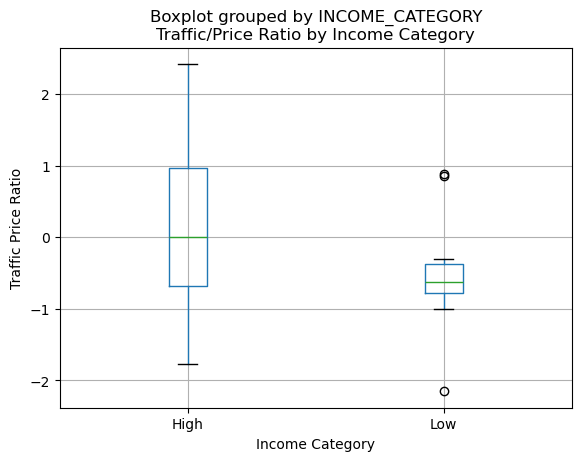

In [58]:
df.boxplot(column="TRAFFIC_PRICE_RATIO", by="INCOME_CATEGORY")

plt.title("Traffic/Price Ratio by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Traffic Price Ratio")

plt.show()

In [59]:
high = df[df["INCOME_CATEGORY"] == "High"]["TRAFFIC_PRICE_RATIO"]
low = df[df["INCOME_CATEGORY"] == "Low"]["TRAFFIC_PRICE_RATIO"]

t_stat, p_val = ttest_ind(high, low, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_val)

t-statistic: 2.282538723864081
p-value: 0.033371620465598176


In [17]:
# cur.close()
connection.close()